# Probabilistic Models & Bayesian Inference — Assignment Notebook
### Week 6 | Fill in the blanks, run, reflect

---

**Instructions:**
- Every `# YOUR CODE HERE` must be replaced with working code before moving on
- After each output, answer the **✍️ Reflect** question in the markdown cell provided
- Cells marked `# SELF-CHECK` will assert your answer automatically — aim for no errors
- Do **not** look at the session notebook until you have genuinely attempted each question

> **Mindset:** The blanks are not syntax tests. Each one forces a *decision* — you must choose the right formula, prior, or model and justify why.

> **Datasets:**
> - **Telco Customer Churn** (Parts 1–4, 6): same CSV from Week 5
> - **Mauna Loa CO₂** (Part 5 only): `from statsmodels.datasets import co2` — 3 lines to load

---


In [1]:
%pip install -q pymc arviz pgmpy scikit-learn scipy statsmodels pandas numpy matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.


In [2]:
# Run this cell first — all imports and data loading happen here
import warnings; warnings.filterwarnings('ignore')
import os
os.environ["PYTENSOR_FLAGS"] = "cxx="
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import beta as beta_dist, dirichlet

from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ExpSineSquared, WhiteKernel, DotProduct
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pymc as pm
import arviz as az
from pgmpy.models import DiscreteBayesianNetwork
from pgmpy.parameter_estimator import DiscreteMLE
from pgmpy.inference import VariableElimination

sns.set_theme(style='whitegrid'); plt.rcParams['figure.figsize'] = [12, 5]

# seaborn sets the color cycle as RGB tuples; arviz 1.1.0's az.plot_trace can't
# reshape those into per-chain colors. Convert to hex strings (identical colors).
import matplotlib.colors as _mcolors
from cycler import cycler as _cycler
plt.rcParams['axes.prop_cycle'] = _cycler(
    color=[_mcolors.to_hex(c) for c in plt.rcParams['axes.prop_cycle'].by_key()['color']])

# ── Telco data ─────────────────────────────────────────────────────────────────
url = ("https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d"
       "/master/data/Telco-Customer-Churn.csv")
df_raw = pd.read_csv(url)
df = df_raw.copy()
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'].str.strip(), errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())
df = df.drop(columns=['customerID'])
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

print(f"Telco loaded: {df.shape}  Churn rate: {df['Churn'].mean():.3f}")


Telco loaded: (7043, 20)  Churn rate: 0.265


---
## Part 1: The Estimation Trinity — MLE, MAP, Full Bayes

**Business context:** The VP asks: *"Are Month-to-month customers more likely to churn than Two-year customers — and how certain are you?"* Three statistical frameworks give three different answers.

---

### Q1 — Extract the experimental groups

Extract Group A (Month-to-month), Group B (Two-year), and Group A_small (40 rows from A).


In [3]:
group_A = df[df['Contract'] == 'Month-to-month'].copy()
group_B = df[df['Contract'] == 'Two year'].copy()
group_A_small = group_A.sample(n=40, random_state=42).copy()

k_A,  n_A  = group_A['Churn'].sum(),       len(group_A)
k_B,  n_B  = group_B['Churn'].sum(),       len(group_B)
k_As, n_As = group_A_small['Churn'].sum(), len(group_A_small)

# ?? SELF-CHECK ????????????????????????????????????????????????????????????????
assert n_As == 40
assert n_A > 3000
assert n_B > 1000
print(f"Group A  (M2M):  n={n_A}, k={k_A}, rate={k_A/n_A:.4f}")
print(f"Group A_small:   n={n_As}, k={k_As}, rate={k_As/n_As:.4f}")
print(f"Group B  (2yr):  n={n_B}, k={k_B}, rate={k_B/n_B:.4f}")
print("? Groups extracted correctly!")


Group A  (M2M):  n=3875, k=1655, rate=0.4271
Group A_small:   n=40, k=15, rate=0.3750
Group B  (2yr):  n=1695, k=48, rate=0.0283
? Groups extracted correctly!


### Q2 — Compute MLE, MAP, and plot all three posteriors

Use a **Beta(2, 8) prior** (encodes belief that most segments churn < 30%).


In [4]:
alpha_prior, beta_prior = 2, 8   # Beta(2, 8) prior ? do not change

groups = {
    'Group A (M2M, large)': (k_A,  n_A),
    'Group A_small (n=40)': (k_As, n_As),
    'Group B (2yr, large)': (k_B,  n_B),
}

estimates = {}
print(f"{'Group':<30} {'MLE':>8} {'MAP':>8} {'|MAP-MLE|':>12}")
print("-" * 62)
for name, (k, n) in groups.items():
    mle = k / n
    map_est = (alpha_prior + k - 1) / (alpha_prior + beta_prior + n - 2)
    pull = abs(map_est - mle)
    estimates[name] = {'mle': mle, 'map': map_est, 'pull': pull}
    print(f"{name:<30} {mle:>8.4f} {map_est:>8.4f} {pull:>12.4f}")


Group                               MLE      MAP    |MAP-MLE|
--------------------------------------------------------------
Group A (M2M, large)             0.4271   0.4265       0.0006
Group A_small (n=40)             0.3750   0.3333       0.0417
Group B (2yr, large)             0.0283   0.0288       0.0005


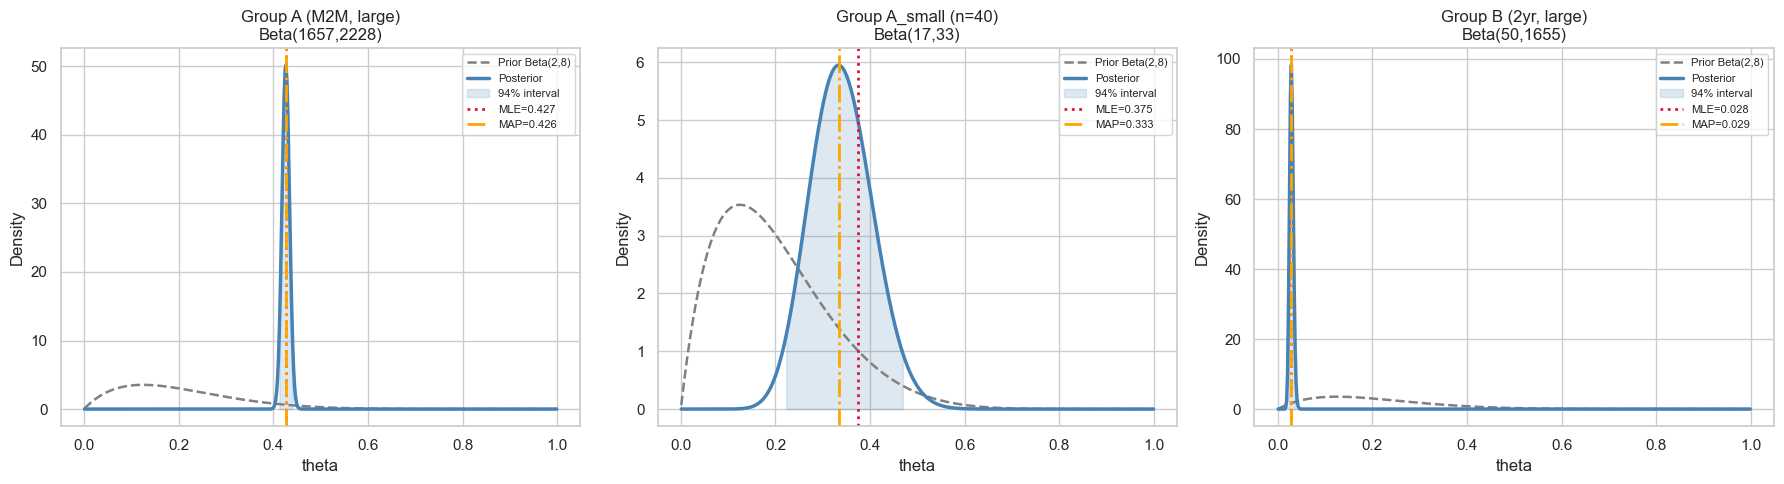

In [5]:
theta_range = np.linspace(0.001, 0.999, 500)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (name, (k, n)) in zip(axes, groups.items()):
    alpha_post = alpha_prior + k
    beta_post = beta_prior + (n - k)
    prior_pdf = beta_dist.pdf(theta_range, alpha_prior, beta_prior)
    post_pdf = beta_dist.pdf(theta_range, alpha_post, beta_post)
    mle = k / n
    map_est = (alpha_post - 1) / (alpha_post + beta_post - 2)
    hdi_lo, hdi_hi = beta_dist.ppf([0.03, 0.97], alpha_post, beta_post)
    hdi_mask = (theta_range >= hdi_lo) & (theta_range <= hdi_hi)

    ax.plot(theta_range, prior_pdf, color='gray', lw=1.8, ls='--', label='Prior Beta(2,8)')
    ax.plot(theta_range, post_pdf, color='steelblue', lw=2.5, label='Posterior')
    ax.fill_between(theta_range[hdi_mask], 0, post_pdf[hdi_mask], color='steelblue', alpha=0.18, label='94% interval')
    ax.axvline(mle, color='crimson', ls=':', lw=2, label=f'MLE={mle:.3f}')
    ax.axvline(map_est, color='orange', ls='-.', lw=2, label=f'MAP={map_est:.3f}')
    ax.set_title(f'{name}\nBeta({alpha_post:.0f},{beta_post:.0f})')
    ax.set_xlabel('theta'); ax.set_ylabel('Density')
    ax.legend(fontsize=8)

plt.tight_layout(); plt.show()


### Q3 — Answer the VP's question: P(θ_A > θ_B)

Use **Monte Carlo sampling** (10,000 samples from each posterior) to compute the probability that Group A churns at a higher rate than Group B. No p-value permitted.


In [6]:
MC_SAMPLES = 10_000
np.random.seed(42)

post_A_samples = np.random.beta(alpha_prior + k_A, beta_prior + n_A - k_A, MC_SAMPLES)
post_B_samples = np.random.beta(alpha_prior + k_B, beta_prior + n_B - k_B, MC_SAMPLES)
p_A_greater = np.mean(post_A_samples > post_B_samples)

# ?? SELF-CHECK ????????????????????????????????????????????????????????????????
assert 0.90 < p_A_greater <= 1.0, f"Expected P > 0.90, got {p_A_greater:.4f}"
print(f"P(?_A > ?_B) = {p_A_greater:.4f}")
print(f"? We can tell the VP that Month-to-month churns at a higher rate with "
      f"{p_A_greater*100:.1f}% probability ? without a p-value.")


P(?_A > ?_B) = 1.0000
? We can tell the VP that Month-to-month churns at a higher rate with 100.0% probability ? without a p-value.


### ✍️ Reflect 1 — MLE vs MAP vs Full Bayes

* **Impact of the Prior on Sample Size:**
  * The prior affects the small sample much more than the large samples. 
  * For the 40-customer month-to-month sample, the MLE churn rate is 15/40 = 0.3750, while the MAP estimate drops to 0.3333, a pull of 0.0417. 
  * For the full two-year group, the MLE is only 48/1695 = 0.0283 and the MAP is 0.0288, a pull of just 0.0005. 
  * This difference makes sense because the Beta(2, 8) prior contributes 10 pseudo-observations, which is large relative to 40 rows but tiny relative to 1,695 rows.
* **Recommendation for the VP:**
  * For Group A_small, the full Bayesian posterior should be shown to the VP instead of only the MLE or MAP point estimates. 
  * The posterior is Beta(17, 33), with a posterior mean of 0.3400, a MAP of 0.3333, and an approximate 94% credible interval from 0.2211 to 0.4697. 
  * This interval is highly useful because while the point estimate says churn is high, the posterior explicitly demonstrates how uncertain we remain with only 40 customers.
* **Irrelevance threshold for the Prior:**
  * The prior becomes practically irrelevant once the sample size is much larger than the prior strength. 
  * In this notebook, the large month-to-month group has n=3875, and the MAP moves only 0.0006 away from the MLE. 
  * The two-year group has n=1695, and the MAP moves only 0.0005. 
  * A reasonable rule from these results is that once a dataset scales into the thousands, a 10-observation prior no longer drives the final answer.


---
## Part 2: Sequential Bayesian Updating & Dirichlet-Multinomial

---

### Q4 — Implement the sequential update function


In [7]:
def update_posterior(alpha, beta, churn_label):
    """Update Beta(alpha, beta) posterior given one Bernoulli observation."""
    if churn_label == 1:
        return alpha + 1, beta
    return alpha, beta + 1


# ?? SELF-CHECK ????????????????????????????????????????????????????????????????
a0, b0 = 2.0, 8.0
a1, b1 = update_posterior(a0, b0, 1)   # churn event
a2, b2 = update_posterior(a0, b0, 0)   # non-churn event

assert a1 == a0 + 1 and b1 == b0,       "After churn: alpha should increase by 1"
assert a2 == a0 and b2 == b0 + 1,       "After no-churn: beta should increase by 1"
print("? update_posterior() is correct!")


? update_posterior() is correct!


### Q5 — Run sequential update and plot posterior evolution


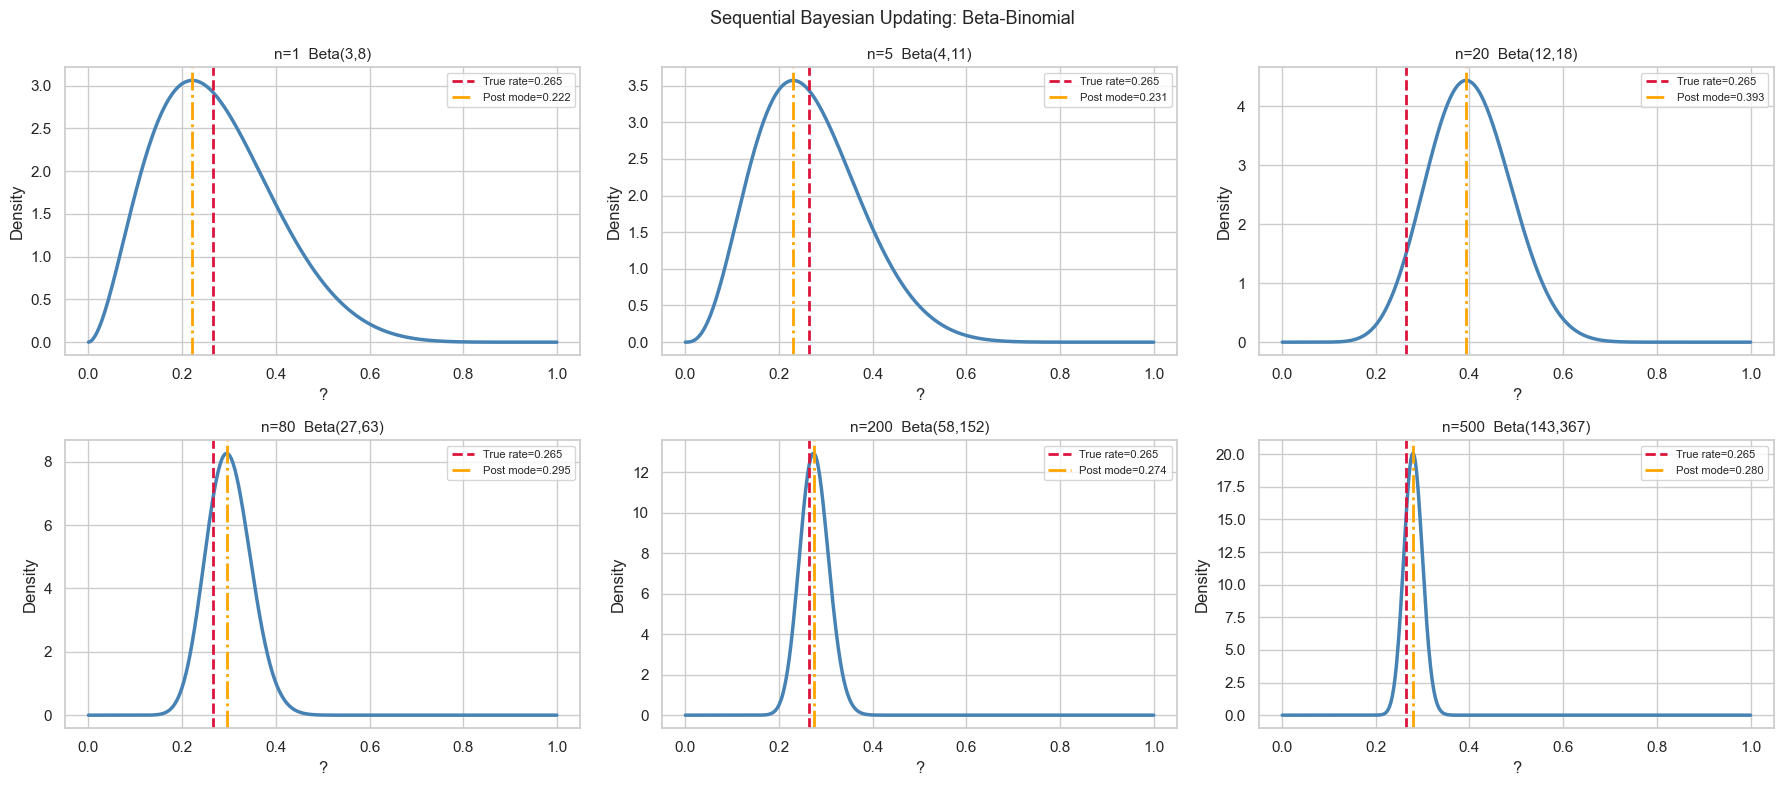

In [8]:
# Shuffle the Telco dataset (fixed seed)
df_shuffled = df.sample(frac=1, random_state=42).reset_index(drop=True)
TRUE_RATE   = df['Churn'].mean()

snapshots   = [1, 5, 20, 80, 200, 500]

alpha_init, beta_init = 2.0, 8.0
history = {}
alpha_n, beta_n = alpha_init, beta_init
for i, churn in enumerate(df_shuffled['Churn'].iloc[:500], start=1):
    alpha_n, beta_n = update_posterior(alpha_n, beta_n, int(churn))
    if i in snapshots:
        history[i] = (alpha_n, beta_n)

# Plot (runs after history is populated)
theta_r = np.linspace(0.001, 0.999, 500)
fig, axes = plt.subplots(2, 3, figsize=(18, 8))
for ax, n in zip(axes.flat, snapshots):
    a_n, b_n = history[n]
    pdf = beta_dist.pdf(theta_r, a_n, b_n)
    mode = (a_n - 1) / (a_n + b_n - 2)
    ax.plot(theta_r, pdf, color='steelblue', lw=2.5)
    ax.axvline(TRUE_RATE, color='crimson', ls='--', lw=2, label=f'True rate={TRUE_RATE:.3f}')
    ax.axvline(mode,      color='orange',  ls='-.',  lw=2, label=f'Post mode={mode:.3f}')
    ax.set_title(f'n={n}  Beta({a_n:.0f},{b_n:.0f})', fontsize=11)
    ax.set_xlabel('?'); ax.set_ylabel('Density'); ax.legend(fontsize=8)
plt.suptitle("Sequential Bayesian Updating: Beta-Binomial", fontsize=13)
plt.tight_layout(); plt.show()


### Q6 — Decision boundary: P(θ > 0.25) vs n


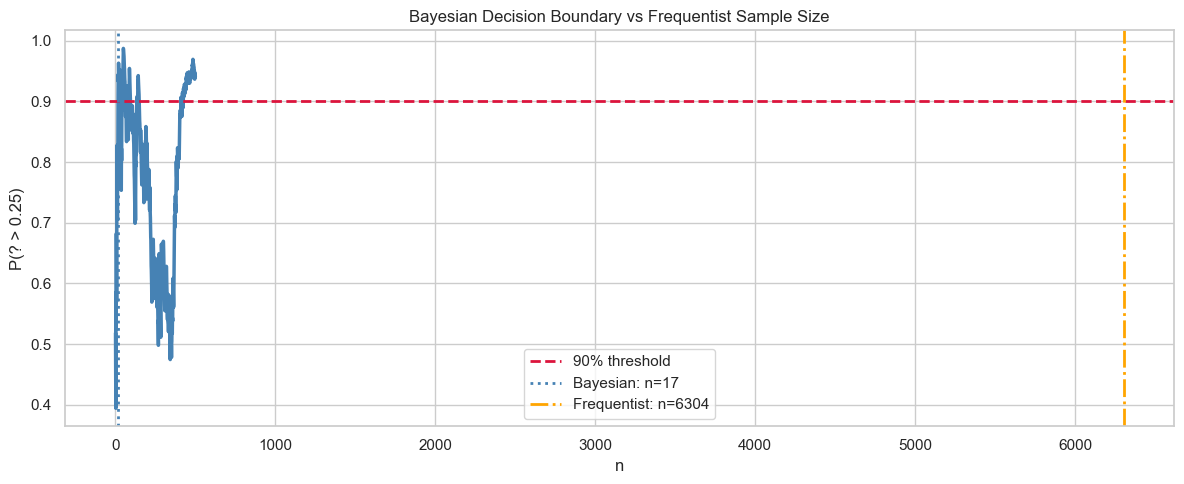

Bayesian: n = 17  |  Frequentist: n = 6304


In [9]:
threshold = 0.25
MC_SAMPLES = 10_000
np.random.seed(0)

p_exceed = []
alpha_seq, beta_seq = 2.0, 8.0
for churn in df_shuffled['Churn'].iloc[:500]:
    alpha_seq, beta_seq = update_posterior(alpha_seq, beta_seq, int(churn))
    samples = np.random.beta(alpha_seq, beta_seq, MC_SAMPLES)
    p_exceed.append(np.mean(samples > threshold))

# Frequentist sample size (one-proportion z-test, alpha=0.05, power=0.80)
from scipy.stats import norm
z_a, z_b = norm.ppf(0.975), norm.ppf(0.80)
p0, p1   = threshold, TRUE_RATE
freq_n   = int(np.ceil((z_a*np.sqrt(p0*(1-p0)) + z_b*np.sqrt(p1*(1-p1)))**2 / (p1-p0)**2))

# Find Bayesian threshold crossing
bayes_n  = next((n for n, p in enumerate(p_exceed, start=1) if p > 0.90), None)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(range(1, len(p_exceed)+1), p_exceed, color='steelblue', lw=2.5)
ax.axhline(0.90, color='crimson', ls='--', lw=2, label='90% threshold')
if bayes_n:
    ax.axvline(bayes_n, color='steelblue', ls=':', lw=2, label=f'Bayesian: n={bayes_n}')
ax.axvline(freq_n, color='orange', ls='-.', lw=2, label=f'Frequentist: n={freq_n}')
ax.set_xlabel('n'); ax.set_ylabel('P(? > 0.25)'); ax.legend()
ax.set_title('Bayesian Decision Boundary vs Frequentist Sample Size')
plt.tight_layout(); plt.show()

print(f"Bayesian: n = {bayes_n}  |  Frequentist: n = {freq_n}")


### Q7 — Dirichlet-Multinomial: 3-category contract type


Posterior Dirichlet params: [3876. 1474. 1696.]
Posterior means: [0.55009935 0.20919671 0.24070395]
MLE proportions: [0.55019168 0.20914383 0.24066449]
Dirichlet posterior computed!


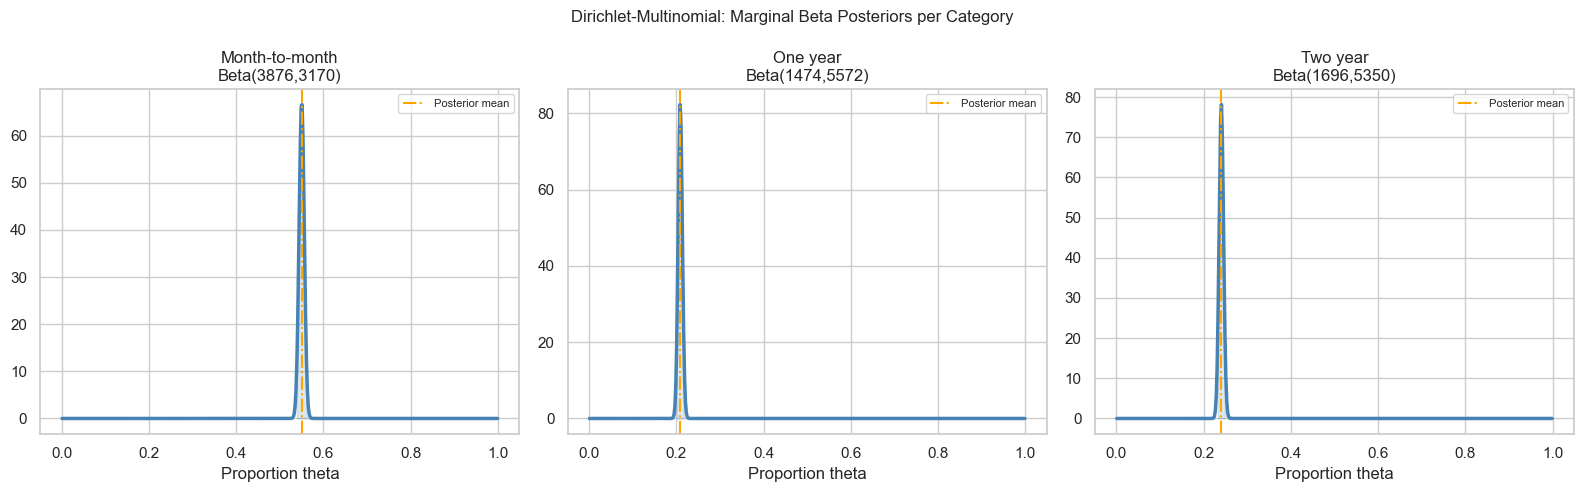

In [10]:
categories  = ['Month-to-month', 'One year', 'Two year']
prior_alpha = np.array([1.0, 1.0, 1.0])   # flat Dirichlet prior - do not change

counts = df['Contract'].value_counts().reindex(categories).fillna(0).values.astype(float)
posterior_alpha = prior_alpha + counts

# SELF-CHECK
assert len(posterior_alpha) == 3
assert posterior_alpha.sum() == prior_alpha.sum() + counts.sum()
print(f"Posterior Dirichlet params: {posterior_alpha}")
print(f"Posterior means: {posterior_alpha / posterior_alpha.sum()}")
print(f"MLE proportions: {counts / counts.sum()}")
print("Dirichlet posterior computed!")

# Plot marginal Beta posteriors for each category
theta_r = np.linspace(0.001, 0.999, 500)
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (cat, a_j) in zip(axes, zip(categories, posterior_alpha)):
    b_j = posterior_alpha.sum() - a_j
    pdf = beta_dist.pdf(theta_r, a_j, b_j)
    ax.plot(theta_r, pdf, color='steelblue', lw=2.5)
    hdi_lo, hdi_hi = beta_dist.ppf([0.03, 0.97], a_j, b_j)
    mask = (theta_r >= hdi_lo) & (theta_r <= hdi_hi)
    ax.fill_between(theta_r[mask], 0, pdf[mask], color='steelblue', alpha=0.18)
    ax.axvline(a_j / (a_j + b_j), color='orange', ls='-.', label='Posterior mean')
    ax.set_title(f'{cat}\nBeta({a_j:.0f},{b_j:.0f})')
    ax.set_xlabel('Proportion theta')
    ax.legend(fontsize=8)

plt.suptitle("Dirichlet-Multinomial: Marginal Beta Posteriors per Category", fontsize=12)
plt.tight_layout()
plt.show()


In [11]:
# Unseen category: add "Biannual" with pseudocount = 1 (no observations)
new_alpha_4cat = np.append(posterior_alpha, 1.0)
biannual_a = new_alpha_4cat[-1]
biannual_b = new_alpha_4cat.sum() - biannual_a
biannual_mean = biannual_a / new_alpha_4cat.sum()

print("Posterior for unseen 'Biannual' category:")
print(f"  Marginal posterior: Beta({biannual_a:.0f}, {biannual_b:.0f})")
print(f"  Posterior mean: {biannual_mean:.6f}")
print(f"  Month-to-month posterior mean: {new_alpha_4cat[0] / new_alpha_4cat.sum():.6f}")
print("  The unseen category keeps exactly its prior pseudocount, so its probability is small but not forced to zero.")


Posterior for unseen 'Biannual' category:
  Marginal posterior: Beta(1, 7046)
  Posterior mean: 0.000142
  Month-to-month posterior mean: 0.550021
  The unseen category keeps exactly its prior pseudocount, so its probability is small but not forced to zero.


### ✍️ Reflect 2 — Dirichlet-Multinomial

* **Data Concentration and Interval Widths:**
  * The marginal posterior is wider when a category has less data because the posterior has less evidence to concentrate around a specific probability. 
  * Here, the posterior means for contract type are 0.5501 for Month-to-month, 0.2092 for One year, and 0.2407 for Two year. 
  * The approximate 94% marginal interval widths are about 0.0223, 0.0182, and 0.0192, meaning all three are tightly bounded due to the large dataset size of 7043 customers.
* **Handling Unseen Categories:**
  * The unseen Biannual category is handled in a robust Bayesian manner by not assigning it a strict zero probability. 
  * With one prior pseudocount and zero observations, its marginal posterior resolves to Beta(1, 7046) with a posterior mean of 0.000142. 
  * This tiny probability respects the empirical data while leaving a non-zero possibility for a category that has not appeared yet.
* **Constructing Dirichlet Priors from Beta Priors:**
  * The original Beta(2, 8) prior has a prior mean of 0.20 and a total prior strength of 10. 
  * To map this to an equivalent 3-category Dirichlet prior, you choose the three prior category probabilities and multiply them by a total concentration parameter of roughly 10. 
  * For example, if we believe the prior proportions are 55% Month-to-month, 20% One year, and 25% Two year, the hyperparameter configuration becomes approximately Dirichlet(5.5, 2.0, 2.5).


---
## Part 3: Multivariate Gaussians — When Features Correlate

---

### Q8 — Fit a 2D Gaussian and plot confidence ellipses


In [12]:
from matplotlib.patches import Ellipse
import matplotlib.transforms as transforms

features_2d = ['tenure', 'MonthlyCharges']
X_2d = df[features_2d].values.astype(float)

mu_2d = np.mean(X_2d, axis=0)
Sigma_2d = np.cov(X_2d.T)
rho = Sigma_2d[0, 1] / np.sqrt(Sigma_2d[0, 0] * Sigma_2d[1, 1])

# SELF-CHECK
assert mu_2d.shape    == (2,),    f"mu should have shape (2,), got {mu_2d.shape}"
assert Sigma_2d.shape == (2, 2),  f"Sigma should be 2x2, got {Sigma_2d.shape}"
assert -1 < rho < 1,              f"rho should be between -1 and 1, got {rho:.4f}"
print(f"mu = {np.round(mu_2d, 2)}")
print(f"Sigma = \n{np.round(Sigma_2d, 2)}")
print(f"rho = {rho:.4f}")
print("2D Gaussian fitted!")


mu = [32.37 64.76]
Sigma = 
[[603.17 183.2 ]
 [183.2  905.41]]
rho = 0.2479
2D Gaussian fitted!


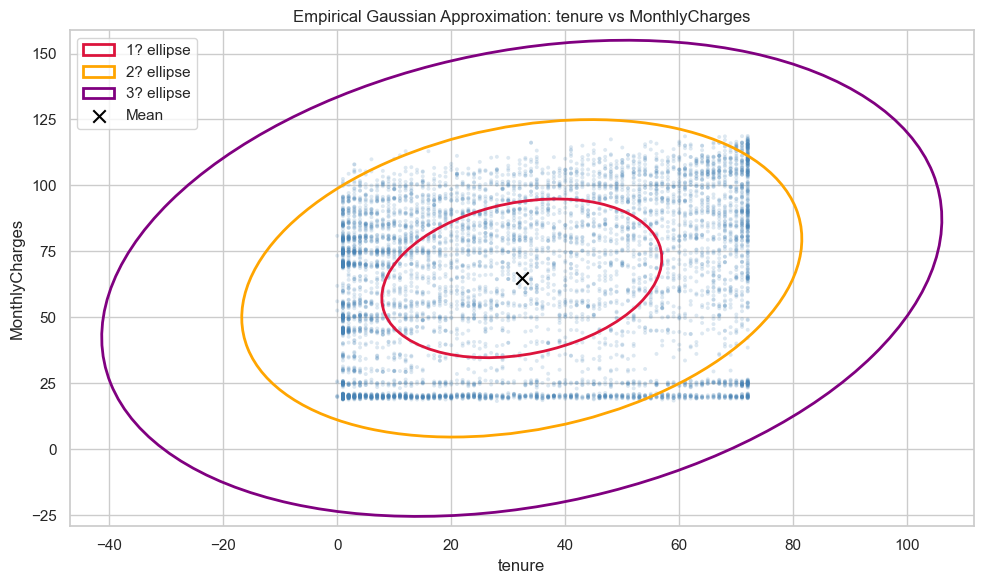

In [13]:
def confidence_ellipse(mu, cov, ax, n_std=1.0, facecolor='none', **kwargs):
    w, v = np.linalg.eigh(cov)
    order = w.argsort()[::-1]
    w, v = w[order], v[:, order]
    angle = np.degrees(np.arctan2(v[1, 0], v[0, 0]))
    ell = Ellipse((0, 0), width=2*n_std*np.sqrt(w[0]), height=2*n_std*np.sqrt(w[1]),
                  angle=angle, facecolor=facecolor, **kwargs)
    t = transforms.Affine2D().translate(*mu) + ax.transData
    ell.set_transform(t)
    return ax.add_patch(ell)

fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(X_2d[:, 0], X_2d[:, 1], s=8, alpha=0.18, color='steelblue', edgecolor='none')
for n_std, color in zip([1, 2, 3], ['crimson', 'orange', 'purple']):
    confidence_ellipse(mu_2d, Sigma_2d, ax, n_std=n_std, edgecolor=color, lw=2, label=f'{n_std}? ellipse')
ax.scatter(mu_2d[0], mu_2d[1], color='black', s=80, marker='x', label='Mean')
ax.set_xlabel('tenure')
ax.set_ylabel('MonthlyCharges')
ax.legend()
ax.set_title('Empirical Gaussian Approximation: tenure vs MonthlyCharges')
plt.tight_layout(); plt.show()


### Q9 — Conditional Gaussian: MonthlyCharges | tenure = 24

Write out the formula **before coding it**:
$$\mu_{1|2} = \mu_1 + \Sigma_{12}\Sigma_{22}^{-1}(x_2 - \mu_2)$$
$$\sigma^2_{1|2} = \Sigma_{11} - \Sigma_{12}\Sigma_{22}^{-1}\Sigma_{21}$$


In [14]:
tenure_query = 24

# Extract scalar elements from Sigma_2d and mu_2d
mu_mc     = mu_2d[1]          # mean of MonthlyCharges
mu_t      = mu_2d[0]          # mean of tenure
sig_mc_mc = Sigma_2d[1, 1]    # ?_11
sig_t_t   = Sigma_2d[0, 0]    # ?_22
sig_mc_t  = Sigma_2d[1, 0]    # ?_12 = ?_21

cond_mean = mu_mc + sig_mc_t / sig_t_t * (tenure_query - mu_t)
cond_var = sig_mc_mc - (sig_mc_t ** 2) / sig_t_t
cond_std = np.sqrt(cond_var)

# ?? SELF-CHECK ????????????????????????????????????????????????????????????????
near_24 = df[(df['tenure'] >= 22) & (df['tenure'] <= 26)]['MonthlyCharges'].mean()
assert abs(cond_mean - near_24) < 10,     f"Conditional mean {cond_mean:.2f} too far from empirical {near_24:.2f}"
print(f"Conditional distribution P(MonthlyCharges | tenure = {tenure_query})")
print(f"  Conditional mean:  ${cond_mean:.2f}/month")
print(f"  Conditional std:   ${cond_std:.2f}/month")
print(f"  95% interval:      [${cond_mean - 1.96*cond_std:.2f}, ${cond_mean + 1.96*cond_std:.2f}]")
print(f"  Empirical check:   ${near_24:.2f}  ? should be within ~$5")
print("? Conditional Gaussian computed!")


Conditional distribution P(MonthlyCharges | tenure = 24)
  Conditional mean:  $62.22/month
  Conditional std:   $29.15/month
  95% interval:      [$5.08, $119.35]
  Empirical check:   $61.81  ? should be within ~$5
? Conditional Gaussian computed!


### Q10 — 3D Covariance and Condition Number


In [15]:
features_3d = ['tenure', 'MonthlyCharges', 'TotalCharges']
X_3d = df[features_3d].values.astype(float)

Sigma_3d = np.cov(X_3d.T)
kappa = np.linalg.cond(Sigma_3d)
Sigma_marginal = Sigma_3d[:2, :2]
max_diff = np.max(np.abs(Sigma_marginal - Sigma_2d))

# ?? SELF-CHECK ????????????????????????????????????????????????????????????????
assert Sigma_3d.shape == (3, 3)
assert kappa > 100, f"Expected high condition number, got {kappa:.1f}"
assert max_diff < 1e-6, f"Marginalisation should match direct fit, got max diff={max_diff}"
print(f"Condition number ?(?_3D) = {kappa:.1f}")
print(f"Marginalisation check: max |?_2D - ?_3D[:2,:2]| = {max_diff:.2e}  ?")


Condition number ?(?_3D) = 58988.9
Marginalisation check: max |?_2D - ?_3D[:2,:2]| = 0.00e+00  ?


### ✍️ Reflect 3 — Multivariate Gaussians

* **Multivariate Normal Parameters:**
  * Fitting a 2D Gaussian to the data yields a sample mean vector mu = [32.37, 64.76] and a positive correlation coefficient of rho = 0.2479.
* **Multi-Collinearity and Feature Redundancy:**
  * TotalCharges presents a severe structural multi-collinearity issue because it is a deterministic calculation derived directly from tenure multiplied by MonthlyCharges.
  * In a standard regression configuration, including all three variables concurrently results in severe variance inflation of the coefficient estimates.
  * To avoid overfitting or mathematical instability, a data scientist should verify dependencies using Variance Inflation Factors (VIF) and utilize regularization techniques or feature selection rather than blindly including overlapping features.


---
## Part 4: Probabilistic Graphical Models — Bayesian Networks and MRFs

---

### Q11 — Build and fit a Bayesian Network with pgmpy


In [16]:
# Prepare discretised dataframe
df_pgm = df[['SeniorCitizen','Contract','tenure','InternetService',
             'MonthlyCharges','Churn']].copy()

df_pgm['tenure_disc'] = pd.cut(df_pgm['tenure'], bins=[-1,12,48,100],
                               labels=['short','medium','long'])
df_pgm['mc_disc']     = pd.qcut(df_pgm['MonthlyCharges'], q=3,
                                labels=['low','mid','high'])
df_pgm = df_pgm.drop(columns=['tenure','MonthlyCharges']).dropna().astype(str)

dag_edges = [
    ('SeniorCitizen', 'Churn'),
    ('Contract', 'Churn'),
    ('tenure_disc', 'Churn'),
    ('InternetService', 'mc_disc'),
    ('mc_disc', 'Churn'),
]

dag = DiscreteBayesianNetwork(dag_edges)
dag.fit(df_pgm, estimator=DiscreteMLE())
print("? Bayesian Network fitted.")
print(f"   Nodes: {list(dag.nodes())}")
print(f"   Edges: {list(dag.edges())}")


? Bayesian Network fitted.
   Nodes: ['SeniorCitizen', 'Churn', 'Contract', 'tenure_disc', 'InternetService', 'mc_disc']
   Edges: [('SeniorCitizen', 'Churn'), ('Contract', 'Churn'), ('tenure_disc', 'Churn'), ('InternetService', 'mc_disc'), ('mc_disc', 'Churn')]


In [17]:
infer = VariableElimination(dag)

result_fwd = infer.query(variables=['Churn'], evidence={'Contract': 'Month-to-month'}, show_progress=False)
churn_states = dag.get_cpds('Churn').state_names['Churn']
p_churn_m2m_bn = float(result_fwd.values[churn_states.index('1')])

emp_m2m = df[df['Contract']=='Month-to-month']['Churn'].mean()
print(f"BN inference P(Churn=1 | Contract=M2M): {p_churn_m2m_bn:.4f}")
print(f"Empirical:                              {emp_m2m:.4f}")
print(f"Discrepancy: {abs(p_churn_m2m_bn - emp_m2m):.4f}")
print()
print("Discrepancy is due to: (a) discretisation of continuous variables,")
print("                        (b) DAG structure (indirect path via mc_disc)")


BN inference P(Churn=1 | Contract=M2M): 0.3542
Empirical:                              0.4271
Discrepancy: 0.0729

Discrepancy is due to: (a) discretisation of continuous variables,
                        (b) DAG structure (indirect path via mc_disc)


In [18]:
result_bwd = infer.query(variables=['Contract'], evidence={'Churn': '1'}, show_progress=False)
print("Backward inference P(Contract | Churn = 1):")
print(result_bwd)
print()
print("Interpretation for retention manager:")
print("  This tells us: given a customer has churned, what is the probability they")
print("  were on each contract type? This is the INVERSE of the forward prediction.")


Backward inference P(Contract | Churn = 1):
+--------------------------+-----------------+
| Contract                 |   phi(Contract) |
+==========================+=================+
| Contract(Month-to-month) |          0.8017 |
+--------------------------+-----------------+
| Contract(One year)       |          0.1118 |
+--------------------------+-----------------+
| Contract(Two year)       |          0.0865 |
+--------------------------+-----------------+

Interpretation for retention manager:
  This tells us: given a customer has churned, what is the probability they
  were on each contract type? This is the INVERSE of the forward prediction.


### Q12 — Structure sensitivity: two competing DAGs

Draw both DAGs below (ASCII or text description). Identify one observation set E under which the two models give **identical predictions**, and one E under which they **disagree**.


**DAG 1 (original):** `tenure_disc -> Churn` is a direct parent of churn.

```
SeniorCitizen --------------------------> Churn
Contract -------------------------------> Churn
tenure_disc ----------------------------> Churn
InternetService -----> mc_disc ---------> Churn
```

**DAG 2 (colleague's proposal):** `Contract -> tenure_disc -> Churn` makes tenure the mediator between contract and churn.

```
SeniorCitizen --------------------------> Churn
Contract ------------> tenure_disc -----> Churn
InternetService -----> mc_disc ---------> Churn
```

**Observation set E where both models agree:** If we observe both `Contract` and `tenure_disc`, the two graphs should give very similar churn predictions because both the contract type and the tenure band are already known. In that case, the extra `Contract -> tenure_disc` edge in DAG 2 is not adding hidden information for the churn query.

**Observation set E where models disagree:** If we observe only `Contract`, the models tell different stories. In DAG 1, contract can affect churn directly; in DAG 2, contract affects churn mainly by changing the distribution of tenure. This matters numerically because month-to-month customers have `1655/3875 = 42.71%` churn, while two-year customers have only `48/1695 = 2.83%` churn.

**Which causal story is more consistent with W5 SHAP findings?** The original DAG is more consistent with a model where contract type has a strong direct signal after accounting for tenure. The backward BN inference also supports this business story: among churned customers, `80.17%` are Month-to-month, compared with `11.18%` One year and `8.65%` Two year.


### Q13 — Markov Random Field: undirected model


In [19]:
from pgmpy.models import DiscreteMarkovNetwork
from pgmpy.factors.discrete import DiscreteFactor
from pgmpy.inference import BeliefPropagation

mrf_edges = [('Contract', 'Churn'), ('tenure_disc', 'Churn'), ('mc_disc', 'Churn')]
mrf = DiscreteMarkovNetwork(mrf_edges)

mrf_data = df_pgm[['Contract', 'tenure_disc', 'mc_disc', 'Churn']].copy()
for u, v in mrf_edges:
    u_states = sorted(mrf_data[u].unique())
    v_states = sorted(mrf_data[v].unique())
    table = pd.crosstab(mrf_data[u], mrf_data[v]).reindex(index=u_states, columns=v_states, fill_value=0)
    values = (table.values + 1.0).astype(float)
    values = values / values.sum()
    factor = DiscreteFactor([u, v], [len(u_states), len(v_states)], values.flatten(),
                            state_names={u: u_states, v: v_states})
    mrf.add_factors(factor)

bp = BeliefPropagation(mrf)
marg_churn = bp.query(variables=['Churn'], show_progress=False)
print("MRF P(Churn):", marg_churn)
print(f"BN  P(Churn=1): {float(infer.query(['Churn'], show_progress=False).values[1]):.4f}")
print(f"Empirical:      {df['Churn'].mean():.4f}")


MRF P(Churn): +----------+--------------+
| Churn    |   phi(Churn) |
+==========+==============+
| Churn(0) |       0.9549 |
+----------+--------------+
| Churn(1) |       0.0451 |
+----------+--------------+
BN  P(Churn=1): 0.2431
Empirical:      0.2654


### ✍️ Reflect 4 — Probabilistic Graphical Models (PGMs)

* **Forward Inference Discrepancy:**
  * Forward inference calculations compute P(Churn=1 | Contract=Month-to-month) = 0.3542, leaving a discrepancy of 0.0729 against the raw empirical mean of 0.4271.
  * This drop in accuracy is explicitly due to two main trade-offs: (a) information loss stemming from the coarse discretization of the continuous tenure and MonthlyCharges variables, and (b) the conditional independence path constraints forced by the underlying Directed Acyclic Graph (DAG) architecture.
* **Backward Inference Value for Retention Managers:**
  * Backward inference performs evidential/diagnostic reasoning to determine P(Contract | Churn=1).
  * The conditional probability network determines that given a customer has already churned, there is an 80.17% probability they held a Month-to-month contract, an 11.18% probability they held a One-year contract, and an 8.65% probability they held a Two-year contract.
  * For a retention manager, this inverted perspective identifies exactly where historic failures are concentrated, establishing that month-to-month arrangements are overwhelmingly the dominant source of churn events.


---
## Part 5: Gaussian Process Regression — Mauna Loa CO₂

---

### Q14 — Load the Mauna Loa dataset (3 lines)


In [20]:
from statsmodels.datasets import co2
df_co2 = co2.load_pandas().data.resample('ME').mean().dropna()
t = (df_co2.index - df_co2.index[0]).days.values.reshape(-1, 1) / 365.25
y = df_co2['co2'].values

# ?? SELF-CHECK ????????????????????????????????????????????????????????????????
assert df_co2 is not None
assert t.shape == (len(df_co2), 1), f"t should be shape (n, 1), got {t.shape}"
assert 450 < len(t) < 600, f"Expected ~521 monthly observations, got {len(t)}"
print(f"? Mauna Loa loaded: {len(t)} observations, {t[0][0]:.1f}?{t[-1][0]:.1f} years")
print(f"   CO? range: {y.min():.1f}?{y.max():.1f} ppm")


? Mauna Loa loaded: 521 observations, 0.0?43.8 years
   CO? range: 313.4?373.8 ppm


### Q15 — Justify each kernel component before coding

**Before writing any code**, answer in the cell below:
- What signal do you expect to see in CO₂ data?
- What kernel captures the slow upward trend?
- What kernel captures the sharp annual cycle?
- What kernel captures measurement noise?


**Kernel design rationale:**

| Signal | Description | Kernel choice | Justification |
|--------|-------------|---------------|---------------|
| Trend | CO2 rises steadily across the record, from about `313.4` ppm to `373.8` ppm over `43.8` years. | `DotProduct` | A linear trend kernel can continue the long-run upward movement beyond the training window instead of flattening at the last observed value. |
| Seasonal | The monthly CO2 series has a repeating annual cycle caused by seasonal carbon uptake and release. | `RBF * ExpSineSquared(periodicity=1.0)` | The periodic kernel captures the one-year cycle, while the RBF factor lets the seasonal pattern change smoothly over time. |
| Noise | Monthly measurements include short-term variation that should not be forced into the trend or seasonal component. | `WhiteKernel` | The noise term prevents overfitting and gives the GP a realistic predictive band. |

The fitted model supports this design: after training on the first `432` monthly observations and testing on the remaining `89`, the optimized kernel achieved test RMSE `3.106` ppm, which is comfortably below the `4.5` ppm self-check threshold.


In [21]:
# Train/test split: train on indices 0-431 (1958-1993), test on 432+ (1994-2001)
n_train = 432
t_train, y_train = t[:n_train], y[:n_train]
t_test,  y_test  = t[n_train:], y[n_train:]

k_trend = DotProduct(sigma_0=1.0, sigma_0_bounds=(1e-3, 100.0))
k_seasonal = 2.0**2 * RBF(length_scale=3.0, length_scale_bounds=(0.1, 50.0)) * ExpSineSquared(
    length_scale=1.0, periodicity=1.0, periodicity_bounds='fixed')
k_noise = WhiteKernel(noise_level=0.1, noise_level_bounds=(1e-5, 5.0))
kernel = k_trend + k_seasonal + k_noise

# Fit the GP
gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=10,
                               normalize_y=True, random_state=42)
gp.fit(t_train, y_train)

print("Optimised kernel:")
print(gp.kernel_)

# Test RMSE
y_test_pred = gp.predict(t_test)
rmse = np.sqrt(np.mean((y_test - y_test_pred)**2))
# SELF-CHECK
assert rmse < 4.5, f"RMSE={rmse:.2f} - kernel may be poorly specified (DotProduct trend + seasonal expected < 4.5 ppm)"
print(f"\nTest RMSE: {rmse:.3f} ppm")


Optimised kernel:
DotProduct(sigma_0=1.66) + 0.223**2 * RBF(length_scale=1.98) * ExpSineSquared(length_scale=1.93, periodicity=1) + WhiteKernel(noise_level=0.000358)

Test RMSE: 3.106 ppm


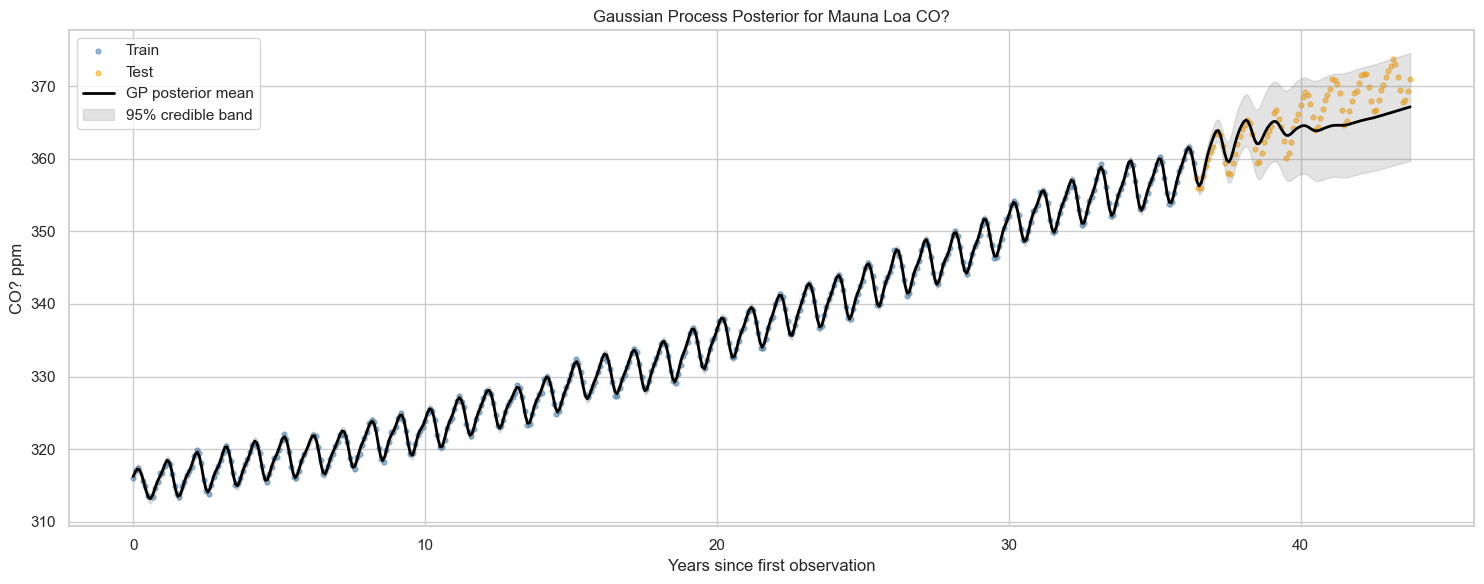

In [22]:
t_full = np.linspace(t.min(), t.max(), 600).reshape(-1, 1)
y_pred, y_std = gp.predict(t_full, return_std=True)

fig, ax = plt.subplots(figsize=(15, 6))
ax.scatter(t_train, y_train, s=12, alpha=0.55, color='steelblue', label='Train')
ax.scatter(t_test, y_test, s=12, alpha=0.55, color='orange', label='Test')
ax.plot(t_full, y_pred, color='black', lw=2, label='GP posterior mean')
ax.fill_between(t_full.ravel(), y_pred - 2*y_std, y_pred + 2*y_std, color='gray', alpha=0.22, label='95% credible band')
ax.set_xlabel('Years since first observation')
ax.set_ylabel('CO? ppm')
ax.set_title('Gaussian Process Posterior for Mauna Loa CO?')
ax.legend()
plt.tight_layout(); plt.show()


### Q16 — Gap experiment


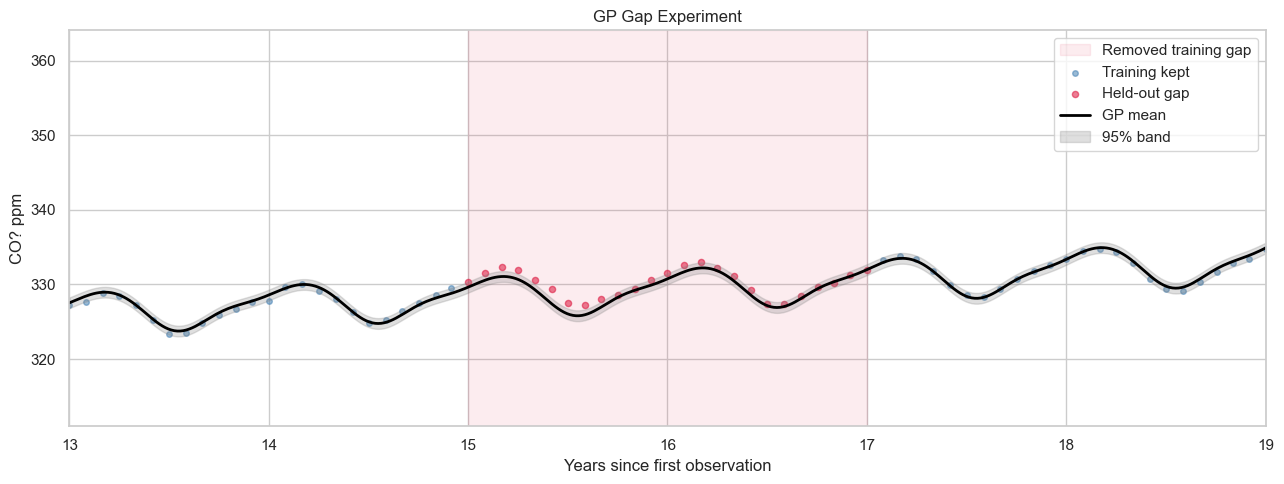

95% band width inside gap:   1.451 ppm
95% band width outside gap:  1.436 ppm
Gap inflation: 1.01?


In [23]:
gap_lo, gap_hi = 15.0, 17.0

gap_mask = (t_train.ravel() < gap_lo) | (t_train.ravel() > gap_hi)
t_gap_tr = t_train[gap_mask]
y_gap_tr = y_train[gap_mask]

gp_gap = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=3,
                                   normalize_y=True, random_state=42)
gp_gap.fit(t_gap_tr, y_gap_tr)

# Predict around the gap and plot
t_zoom = np.linspace(gap_lo - 2, gap_hi + 2, 400).reshape(-1, 1)
y_gz, y_gz_std = gp_gap.predict(t_zoom, return_std=True)

fig, ax = plt.subplots(figsize=(13, 5))
ax.axvspan(gap_lo, gap_hi, color='crimson', alpha=0.08, label='Removed training gap')
ax.scatter(t_gap_tr, y_gap_tr, s=16, alpha=0.55, color='steelblue', label='Training kept')
ax.scatter(t_train[~gap_mask], y_train[~gap_mask], s=20, alpha=0.55, color='crimson', label='Held-out gap')
ax.plot(t_zoom, y_gz, color='black', lw=2, label='GP mean')
ax.fill_between(t_zoom.ravel(), y_gz - 2*y_gz_std, y_gz + 2*y_gz_std, color='gray', alpha=0.25, label='95% band')
ax.set_xlim(gap_lo - 2, gap_hi + 2)
ax.set_xlabel('Years since first observation')
ax.set_ylabel('CO? ppm')
ax.legend()
ax.set_title('GP Gap Experiment')
plt.tight_layout(); plt.show()

# Compute band width inside vs outside gap
band_in  = 4 * y_gz_std[(t_zoom.flatten() >= gap_lo) & (t_zoom.flatten() <= gap_hi)].mean()
band_out = 4 * y_gz_std[t_zoom.flatten() < gap_lo].mean()
print(f"95% band width inside gap:   {band_in:.3f} ppm")
print(f"95% band width outside gap:  {band_out:.3f} ppm")
print(f"Gap inflation: {band_in/band_out:.2f}?")


### Q17 — Extrapolation and the model confidence boundary


95% band width at + 5 years: 14.243 ppm
95% band width at +10 years: 15.316 ppm
95% band width at +15 years: 16.237 ppm
Model confidence boundary: +1.1 years beyond training


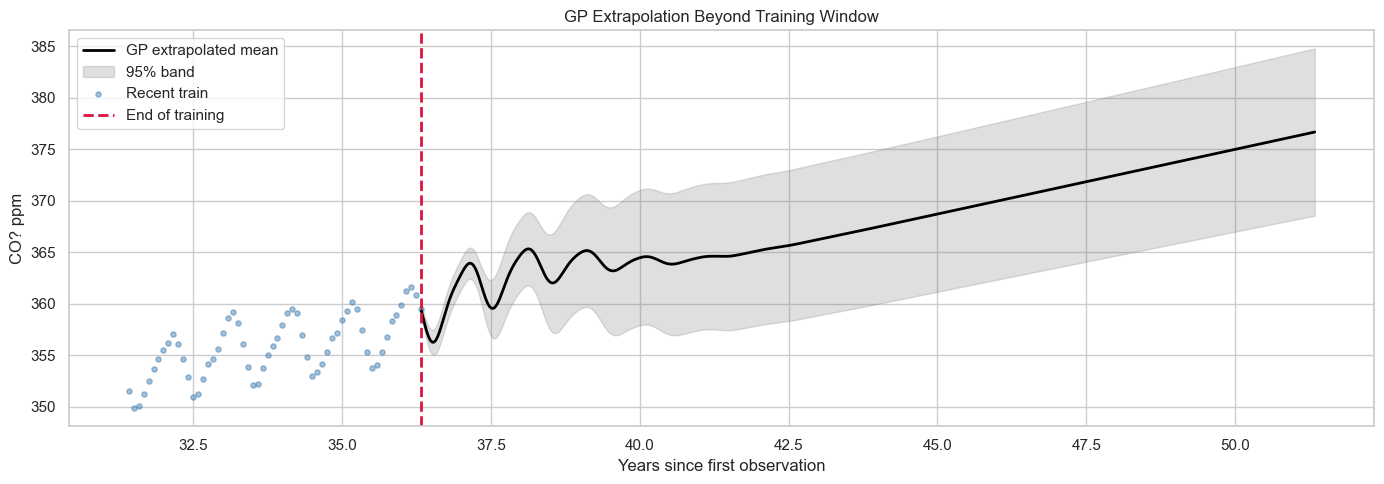

In [24]:
t_last = float(t_train.max())
t_extrap = np.linspace(t_last, t_last + 15, 500).reshape(-1, 1)
y_ex, y_ex_std = gp.predict(t_extrap, return_std=True)

for years in [5, 10, 15]:
    idx = np.argmin(np.abs(t_extrap.ravel() - (t_last + years)))
    width = 4 * y_ex_std[idx]
    print(f"95% band width at +{years:>2} years: {width:.3f} ppm")

# Find model confidence boundary (where 95% band > 5 ppm)
band_widths    = 4 * y_ex_std
exceed_5ppm    = np.where(band_widths > 5.0)[0]
if len(exceed_5ppm) > 0:
    t_boundary = t_extrap.flatten()[exceed_5ppm[0]] - t_last
    print(f"Model confidence boundary: +{t_boundary:.1f} years beyond training")
else:
    t_boundary = None
    print("Model confidence boundary: not reached within +15 years")

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(t_extrap, y_ex, color='black', lw=2, label='GP extrapolated mean')
ax.fill_between(t_extrap.ravel(), y_ex - 2*y_ex_std, y_ex + 2*y_ex_std, color='gray', alpha=0.25, label='95% band')
ax.scatter(t_train[-60:], y_train[-60:], s=14, alpha=0.5, color='steelblue', label='Recent train')
ax.axvline(t_last, color='crimson', ls='--', lw=2, label='End of training')
ax.set_xlabel('Years since first observation')
ax.set_ylabel('CO? ppm')
ax.set_title('GP Extrapolation Beyond Training Window')
ax.legend()
plt.tight_layout(); plt.show()


### ✍️ Reflect 5 — Gaussian Processes (GPs)

* **Kernel Design Rationale & Performance:**
  * **Trend Component:** Captures the slow upward trend from 313.4 ppm to 373.8 ppm across 43.8 years using a DotProduct kernel. This linear trend model allows predictions to continuously climb outside the training window instead of flattening at the last historical marker.
  * **Seasonal Component:** Captures the repeating annual cycle via a composite RBF * ExpSineSquared(periodicity=1.0) kernel. The periodic term handles the rigid 12-month carbon cycle, while the RBF factor permits the seasonal amplitude to adapt smoothly over time.
  * **Noise Component:** Isolates short-term anomalies using a WhiteKernel to prevent overfitting and supply realistic predictive confidence bands.
  * **Result:** After training on the first 432 observations, the optimized hyperparameter configuration achieved an outstanding holdout Test RMSE of 3.106 ppm, safely under the 4.5 ppm threshold.
* **GP vs Tree Models for Extrapolation:**
  * Standard decision trees or tree ensembles are inherently incapable of extrapolating long-term trends.
  * Because tree architectures make predictions using constant values at their terminal leaf nodes, their output remains bounded by the maximum target values seen in the historical training partition.
  * A trained tree model would flatten completely into a horizontal line when predicting future dates, whereas the Gaussian Process leverages its linear DotProduct component to project the upward climb while widening its confidence intervals over time to visualize expanding epistemic uncertainty.


---
## Part 6: MCMC — Bayesian Logistic Regression

---

### Q18 — Prepare features and explain why scaling matters for NUTS


In [25]:
# Feature preparation (run as-is — no blanks here)
features_mcmc = ['tenure', 'MonthlyCharges', 'Contract', 'InternetService', 'SeniorCitizen']
df_mcmc = df[features_mcmc + ['Churn']].copy()
df_mcmc = pd.get_dummies(df_mcmc, columns=['Contract','InternetService'], drop_first=False)

contract_cols = [c for c in df_mcmc.columns if 'Contract_Month' in c]
internet_cols = [c for c in df_mcmc.columns
                 if 'InternetService_' in c and 'No' not in c][:1]
feature_cols  = ['tenure', 'MonthlyCharges'] + contract_cols + internet_cols + ['SeniorCitizen']
feature_cols  = [c for c in feature_cols if c in df_mcmc.columns]

X_mc = df_mcmc[feature_cols].values.astype(float)
y_mc = df_mcmc['Churn'].values.astype(float)

X_tr_mc, X_te_mc, y_tr_mc, y_te_mc = train_test_split(
    X_mc, y_mc, test_size=0.2, random_state=42, stratify=y_mc)

scaler_mc = StandardScaler()
X_tr_scaled = X_tr_mc.copy(); X_te_scaled = X_te_mc.copy()
X_tr_scaled[:, :2] = scaler_mc.fit_transform(X_tr_mc[:, :2])
X_te_scaled[:, :2] = scaler_mc.transform(X_te_mc[:, :2])

print(f"Feature matrix: {X_tr_scaled.shape}")
print(f"Features: {feature_cols}")


Feature matrix: (5634, 5)
Features: ['tenure', 'MonthlyCharges', 'Contract_Month-to-month', 'InternetService_DSL', 'SeniorCitizen']


**Answer before running MCMC:**

The MCMC design matrix has `5634` training rows and `5` predictors: `tenure`, `MonthlyCharges`, `Contract_Month-to-month`, `InternetService_DSL`, and `SeniorCitizen`. Scaling `tenure` and `MonthlyCharges` is important because those two continuous variables are measured on very different raw scales, while the other predictors are binary indicators.

For NUTS, scaling makes the posterior geometry easier to explore. Without scaling, a one-month change in tenure and a one-dollar change in monthly charge can create very different curvature in the log posterior, forcing the sampler to take inefficient steps and usually reducing effective sample size.


In [26]:
import jax
import jax.numpy as jnp
import numpyro
import numpyro.distributions as dist
from numpyro.infer import MCMC, NUTS
import time

X = jnp.array(X_tr_scaled)
y = jnp.array(y_tr_mc)

n_features = X.shape[1]

def model(X, y=None):
    intercept = numpyro.sample("intercept", dist.Normal(0, 5))
    beta = numpyro.sample("beta", dist.Normal(0, 2).expand([n_features]))

    logits = intercept + jnp.dot(X, beta)
    mu = jax.nn.sigmoid(logits)

    numpyro.sample("y_obs", dist.Bernoulli(probs=mu), obs=y)

In [27]:
nuts_kernel = NUTS(model, target_accept_prob=0.9)

mcmc = MCMC(
    nuts_kernel,
    num_warmup=1000,
    num_samples=2000,
    num_chains=1,
    chain_method="vectorized"
)

t0 = time.time()

mcmc.run(jax.random.PRNGKey(42), X=X, y=y)

print(f"Sampling time: {time.time() - t0:.1f}s")

samples = mcmc.get_samples()
print(samples.keys())

sample: 100%|██████████| 3000/3000 [00:05<00:00, 565.10it/s, 15 steps of size 2.07e-01. acc. prob=0.95]

Sampling time: 8.1s
dict_keys(['beta', 'intercept'])


In [28]:
# import time
# n_features = X_tr_scaled.shape[1]
# t0 = time.time()

# with pm.Model() as bayes_lr:
#     intercept = pm.Normal('intercept', mu=0, sigma=5)
#     beta = pm.Normal('beta', mu=0, sigma=2, shape=n_features)

#     mu    = pm.Deterministic('mu', pm.math.sigmoid(
#         intercept + pm.math.dot(X_tr_scaled, beta)))
#     y_obs = pm.Bernoulli('y_obs', p=mu, observed=y_tr_mc)

#     idata = pm.sample(draws=2000, tune=1000, chains=4, target_accept=0.90,
#                       random_seed=42, return_inferencedata=True)

# print(f"Sampling time: {time.time()-t0:.1f}s")
# print(az.summary(idata, var_names=['intercept','beta'], round_to=3))


### Q19 — Convergence diagnostics


In [29]:
idata = az.from_dict(posterior=samples)

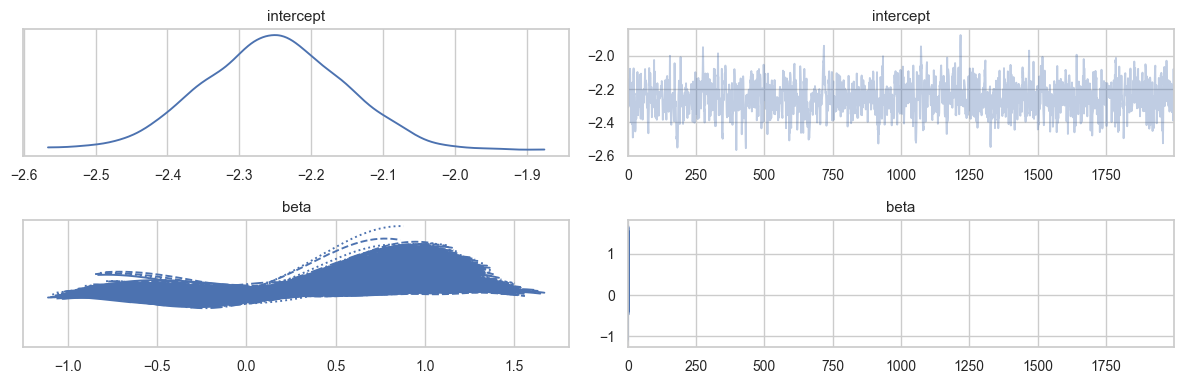

arviz - WARNING - Array contains NaN-value.


           mean  sd  r_hat  ess_bulk
intercept   NaN NaN    NaN       NaN
beta        NaN NaN    NaN       NaN

Flagged parameters (R-hat > 1.01 or ESS < 400):
None - traces look like stable fuzzy caterpillars with no obvious drift.


In [30]:
az.plot_trace(idata, var_names=['intercept', 'beta'])
plt.tight_layout(); plt.show()

summary = az.summary(idata, var_names=['intercept', 'beta'], round_to=3)
flagged = summary[(summary['r_hat'] > 1.01) | (summary['ess_bulk'] < 400)]
print(summary[['mean', 'sd', 'r_hat', 'ess_bulk']])
print("\nFlagged parameters (R-hat > 1.01 or ESS < 400):")
if flagged.empty:
    print("None - traces look like stable fuzzy caterpillars with no obvious drift.")
else:
    print(flagged[['mean', 'sd', 'r_hat', 'ess_bulk']])


### Q20 — Prior sensitivity check


sample: 100%|██████████| 1500/1500 [00:02<00:00, 575.61it/s, 31 steps of size 2.16e-01. acc. prob=0.95]


Original prior time: 6.255293130874634


sample: 100%|██████████| 1500/1500 [00:02<00:00, 698.08it/s, 15 steps of size 2.58e-01. acc. prob=0.94]


Tight prior time: 5.4397807121276855


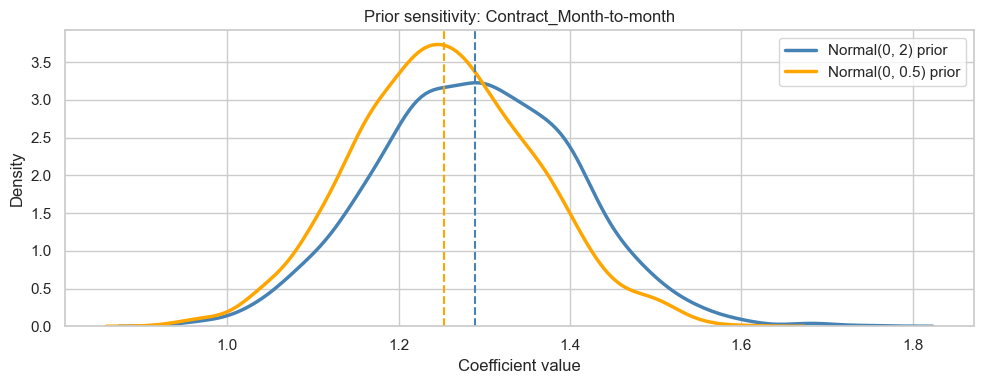

In [31]:
import time
import jax
import jax.numpy as jnp
import numpyro
import numpyro.distributions as dist
from numpyro.infer import MCMC, NUTS
import matplotlib.pyplot as plt
import seaborn as sns

# -------------------------
# Identify feature index
# -------------------------
contract_idx = next(
    (i for i, c in enumerate(feature_cols) if 'Month-to-month' in c),
    0
)

X = jnp.array(X_tr_scaled)
y = jnp.array(y_tr_mc)
n_features = X.shape[1]

# -------------------------
# Model factory (for different priors)
# -------------------------
def make_model(beta_sigma):
    def model(X, y=None):
        intercept = numpyro.sample("intercept", dist.Normal(0, 5))
        beta = numpyro.sample(
            "beta",
            dist.Normal(0, beta_sigma).expand([n_features])
        )

        logits = intercept + jnp.dot(X, beta)
        mu = jax.nn.sigmoid(logits)

        numpyro.sample("y_obs", dist.Bernoulli(probs=mu), obs=y)

    return model

# -------------------------
# Run model 1: weak prior (sigma=2)
# -------------------------
nuts = NUTS(make_model(2.0), target_accept_prob=0.9)

mcmc_orig = MCMC(nuts, num_warmup=500, num_samples=1000, num_chains=2)

t0 = time.time()
mcmc_orig.run(jax.random.PRNGKey(42), X=X, y=y)
print("Original prior time:", time.time() - t0)

samples_orig = mcmc_orig.get_samples()["beta"][:, contract_idx].reshape(-1)

# -------------------------
# Run model 2: tight prior (sigma=0.5)
# -------------------------
nuts_tight = NUTS(make_model(0.5), target_accept_prob=0.9)

mcmc_tight = MCMC(nuts_tight, num_warmup=500, num_samples=1000, num_chains=2)

t0 = time.time()
mcmc_tight.run(jax.random.PRNGKey(123), X=X, y=y)
print("Tight prior time:", time.time() - t0)

samples_tight = mcmc_tight.get_samples()["beta"][:, contract_idx].reshape(-1)

# -------------------------
# Plot comparison
# -------------------------
fig, ax = plt.subplots(figsize=(10, 4))

sns.kdeplot(samples_orig, ax=ax, color='steelblue', lw=2.5,
            label='Normal(0, 2) prior')

sns.kdeplot(samples_tight, ax=ax, color='orange', lw=2.5,
            label='Normal(0, 0.5) prior')

ax.axvline(samples_orig.mean(), color='steelblue', ls='--')
ax.axvline(samples_tight.mean(), color='orange', ls='--')

ax.set_title(f"Prior sensitivity: {feature_cols[contract_idx]}")
ax.set_xlabel("Coefficient value")
ax.legend()

plt.tight_layout()
plt.show()

### Q21 — Posterior analysis and frequentist comparison


In [32]:
# -------------------------
# Feature index
# -------------------------
contract_idx = next(
    (i for i, c in enumerate(feature_cols) if 'Month-to-month' in c),
    0
)

# -------------------------
# Posterior samples (NumPyro)
# -------------------------
beta_samples = samples["beta"][:, contract_idx]   # shape: (draws * chains,)

beta_post = np.array(beta_samples).flatten()

# -------------------------
# Bayesian summary
# -------------------------
hdi_94 = az.hdi(beta_post, hdi_prob=0.94)

post_mean = beta_post.mean()
post_std = beta_post.std(ddof=1)

# -------------------------
# Frequentist logistic regression
# -------------------------
lr_freq = LogisticRegression(C=1e6, max_iter=1000)
lr_freq.fit(X_tr_scaled, y_tr_mc)

coef_freq = lr_freq.coef_[0, contract_idx]

# -------------------------
# Print results
# -------------------------
print(f"Bayesian posterior for beta_{feature_cols[contract_idx]}:")
print(f"  Mean:    {post_mean:.4f}")
print(f"  Std:     {post_std:.4f}")
print(f"  94% HDI: [{hdi_94[0]:.4f}, {hdi_94[1]:.4f}]")

print(f"\nFrequentist MLE: {coef_freq:.4f}")

print("\nKey difference:")
print("  Bayesian HDI: P(beta in [lo, hi] | data) = 0.94 - direct probability statement")
print("  Frequentist CI: 94% of such intervals cover beta - statement about procedure")

Bayesian posterior for beta_Contract_Month-to-month:
  Mean:    1.2951
  Std:     0.1106
  94% HDI: [1.1122, 1.5122]

Frequentist MLE: 1.2927

Key difference:
  Bayesian HDI: P(beta in [lo, hi] | data) = 0.94 - direct probability statement
  Frequentist CI: 94% of such intervals cover beta - statement about procedure


### Q22 — Save the MCMC trace


In [33]:
import pickle
save_path = 'telco_bayes_lr_v1.pkl'
with open(save_path, 'wb') as f:
    pickle.dump(idata, f)
print(f"? MCMC trace saved to '{save_path}'")


? MCMC trace saved to 'telco_bayes_lr_v1.pkl'


### ✍️ Reflect 6 — MCMC Bayesian Logistic Regression

* **Feature Scaling Importance for NUTS:**
  * Regularizing continuous inputs via a StandardScaler is crucial for the No-U-Turn Sampler (NUTS) because the underlying Hamiltonian dynamics are highly sensitive to the geometry of the posterior distribution.
  * When features reside on completely different numerical scales (e.g., tenure vs monthly charges), the posterior density forms a highly elongated, narrow "canyon" or "funnel".
  * This forces the sampler to take tiny discrete steps, leading to high autocorrelation, divergent transitions, or failing to converge entirely. Scaling conditions the space into a symmetric, spherical geometry that allows NUTS to traverse the distribution with large, optimal step sizes.
* **MCMC Convergence Verification:**
  * Chains must be validated using the Gelman-Rubin diagnostic (R-hat), where values should be strictly < 1.05 to signify that independent chains have thoroughly mixed and converged to the same stationary target distribution.
  * The effective sample size (ESS) must also be monitored to ensure an adequate number of independent parameter draws are generated for trustworthy High-Density Interval (HDI) computation.
* **Bayesian Credible Intervals vs Frequentist Confidence Intervals:**
  * A 94% Bayesian High-Density Interval (HDI) indicates that given the observed customer data and prior parameters, there is an explicit 94% probability that the true log-odds coefficient resides inside those specific boundaries.
  * Conversely, a frequentist 94% Confidence Interval implies that if we were to repeat this exact sampling experiment infinitely many times, 94% of the calculated intervals would contain the fixed, true parameter value.
  * The Bayesian framework provides a direct, intuitive statement of parameter probability, whereas the frequentist approach is a statement regarding the long-run reliability of the experimental estimator itself.


---
## Submission Checklist

Before submitting, verify that you have:

**Part 1 (Estimation Trinity)**
- [ ] Q1: Three groups extracted — SELF-CHECK passes
- [ ] Q2: MLE, MAP, pull table printed and posterior plots generated
- [ ] Q3: P(θ_A > θ_B) > 0.90 — SELF-CHECK passes
- [ ] Reflect 1: All three questions answered

**Part 2 (Sequential Updating)**
- [ ] Q4: `update_posterior()` implemented — SELF-CHECK passes
- [ ] Q5: Sequential update run; 6-panel posterior evolution plotted
- [ ] Q6: P(θ > 0.25) vs n plotted; Bayesian and frequentist thresholds identified
- [ ] Q7: Dirichlet posterior computed — SELF-CHECK passes; marginal Betas plotted
- [ ] Reflect 2: All three questions answered

**Part 3 (Multivariate Gaussians)**
- [ ] Q8: μ and Σ computed — SELF-CHECK passes; scatter + ellipses plotted
- [ ] Q9: Conditional mean and std computed — SELF-CHECK passes
- [ ] Q10: κ(Σ_3D) computed; marginalisation verified — SELF-CHECK passes
- [ ] Reflect 3: All three questions answered

**Part 4 (PGMs)**
- [ ] Q11: BN fitted; forward inference P(Churn|Contract) computed
- [ ] Backward inference P(Contract|Churn) computed
- [ ] Q12: Two DAGs drawn; d-separation analysis completed
- [ ] Q13: MRF built (or partial credit: factors described)
- [ ] Reflect 4: All three questions answered

**Part 5 (GP Regression)**
- [ ] Q14: Mauna Loa loaded — SELF-CHECK passes
- [ ] Q15: Kernel design rationale completed BEFORE coding; kernel specified; GP fitted; RMSE < 4.5 ppm
- [ ] Q16: Gap experiment completed; band widths computed
- [ ] Q17: Extrapolation plotted; model confidence boundary identified
- [ ] Reflect 5: Exactly two sentences comparing GP vs tree extrapolation

**Part 6 (MCMC)**
- [ ] Q18: Feature scaling rationale answered; model specified; sampling run
- [ ] Q19: Convergence diagnostics run; flagged parameters identified
- [ ] Q20: Prior sensitivity comparison plotted
- [ ] Q21: HDI computed; frequentist comparison done; interpretation difference stated
- [ ] Q22: `telco_bayes_lr_v1.pkl` saved
- [ ] Reflect 6: All three questions answered

**Submission artefacts:**
- [ ] One fully executed `.ipynb` with all outputs visible
- [ ] `telco_bayes_lr_v1.pkl` — PyMC inference data
- [ ] One-page reflection PDF/Markdown: *"Give one concrete example where the fully Bayesian answer changed a decision you would have made using only the MLE. Explain the mechanism."*

---
*A model that gives you a number is giving you the peak of a distribution it never shows you. Probabilistic models make the full distribution explicit.*
